In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/kgueye/creditcardfraud/creditcard.csv")

print("Shape:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nTypes:\n", df.dtypes)
print("\nAperçu:\n", df.head(3))

Shape: (284807, 31)

Colonnes: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Aperçu:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1

### Observation
Le dataset contient **284 807 transactions** et **31 colonnes** :
- `Time` : secondes écoulées depuis la première transaction (≈ 48h de données)
- `V1` à `V28` : composantes PCA — les vraies features sont anonymisées par la banque
- `Amount` : montant en euros, seule feature métier lisible
- `Class` : cible binaire — 0 légitime, 1 fraude

Tous les types sont `float64` sauf `Class` en `int64`. Aucun encodage nécessaire.

In [2]:
print("=== Valeurs manquantes ===")
print(df.isnull().sum().sum(), "valeur(s) manquante(s) au total")

print("\n=== Distribution de la cible ===")
counts = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True) * 100
print(f"Légitimes  (0): {counts[0]:,}  ({pct[0]:.3f}%)")
print(f"Fraudes    (1): {counts[1]:,}  ({pct[1]:.3f}%)")
print(f"\nRatio déséquilibre: 1 fraude pour {counts[0]//counts[1]} légitimes")

=== Valeurs manquantes ===
0 valeur(s) manquante(s) au total

=== Distribution de la cible ===
Légitimes  (0): 284,315  (99.827%)
Fraudes    (1): 492  (0.173%)

Ratio déséquilibre: 1 fraude pour 577 légitimes


In [3]:
print("=== Statistiques sur Amount ===")
print(df['Amount'].describe().round(2))

print("\n=== Statistiques sur Time ===")
print(df['Time'].describe().round(2))

print("\n=== Amount moyen : fraude vs légitime ===")
print(df.groupby('Class')['Amount'].describe().round(2))

=== Statistiques sur Amount ===
count    284807.00
mean         88.35
std         250.12
min           0.00
25%           5.60
50%          22.00
75%          77.16
max       25691.16
Name: Amount, dtype: float64

=== Statistiques sur Time ===
count    284807.00
mean      94813.86
std       47488.15
min           0.00
25%       54201.50
50%       84692.00
75%      139320.50
max      172792.00
Name: Time, dtype: float64

=== Amount moyen : fraude vs légitime ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


### Observation

**Amount — distribution asymétrique (skewed right)**
- Moyenne = 88€, médiane = 22€ → quelques très grosses transactions tirent la moyenne vers le haut
- Max à 25 691€, std à 250 pour une moyenne de 88 → dispersion extrême
- Conséquence : il faudra appliquer `log1p(Amount)` ou `StandardScaler` avant la modélisation
  pour ne pas biaiser les algorithmes sensibles aux échelles

**Time — 48 heures de données**
- Max = 172 792 secondes ÷ 3600 = 48h exactement
- En l'état peu utile, mais on pourra extraire `Time % 86400 // 3600` pour obtenir
  l'heure de la journée et détecter des patterns nocturnes

**Fraude vs Légitime sur Amount**

| | Moyenne | Médiane | Max |
|---|---|---|---|
| Légitime | 88€ | 22€ | 25 691€ |
| Fraude | 122€ | 9€ | 2 125€ |

Deux comportements frauduleux distincts :
- **Petites fraudes** (médiane 9€) : test de carte avec 1-2€ pour vérifier qu'elle est active
- **Fraudes moyennes** : quelques montants plus élevés qui tirent la moyenne à 122€

Les fraudeurs évitent les très gros montants (max fraude = 2 125€ vs 25 691€ légitime)
pour ne pas déclencher les alertes automatiques — comportement classique appelé **structuring**.

## 3. Visualisation — distribution des montants

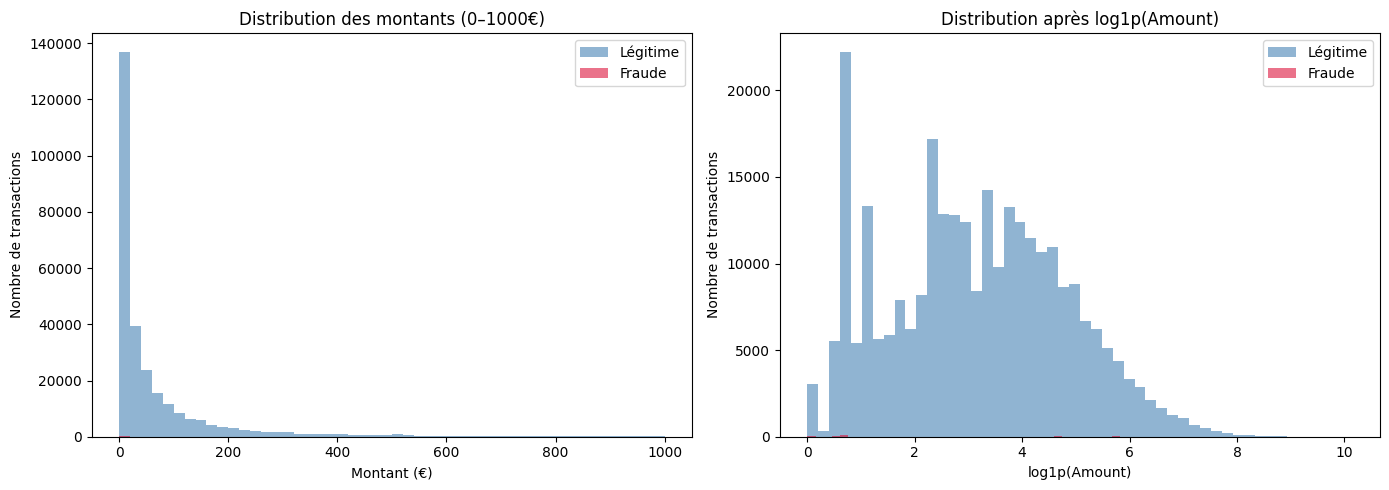

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[0].hist(legit, bins=50, alpha=0.6, label='Légitime', color='steelblue', range=(0, 1000))
axes[0].hist(fraud, bins=50, alpha=0.6, label='Fraude', color='crimson', range=(0, 1000))
axes[0].set_title('Distribution des montants (0–1000€)')
axes[0].set_xlabel('Montant (€)')
axes[0].set_ylabel('Nombre de transactions')
axes[0].legend()

axes[1].hist(np.log1p(legit), bins=50, alpha=0.6, label='Légitime', color='steelblue')
axes[1].hist(np.log1p(fraud), bins=50, alpha=0.6, label='Fraude', color='crimson')
axes[1].set_title('Distribution après log1p(Amount)')
axes[1].set_xlabel('log1p(Amount)')
axes[1].set_ylabel('Nombre de transactions')
axes[1].legend()

plt.tight_layout()
plt.show()

### Observation

**Graphique gauche — Distribution brute (0–1000€)**
La quasi-totalité des transactions légitimes se concentre sous 100€, avec un pic massif
près de zéro. La courbe descend très vite — c'est la **longue queue droite** confirmée.
Les fraudes (en rouge) sont quasi invisibles à cette échelle : le déséquilibre de classes
écrase visuellement la minorité. C'est exactement le problème qu'on devra résoudre.

**Graphique droit — Après log1p(Amount)**
Le `log1p` compresse les grandes valeurs et étire les petites.
On voit maintenant la vraie forme de la distribution légitime : **multimodale**
(plusieurs pics), ce qui suggère des comportements d'achat distincts
(petits achats quotidiens, achats moyens, achats importants).

Les fraudes restent collées à gauche (valeurs log1p faibles = petits montants),
ce qui confirme le comportement de **test de carte** observé dans les stats descriptives.

**Décision :** on utilisera `log1p(Amount)` comme feature dans nos modèles
plutôt que `Amount` brut pour ne pas biaiser les algorithmes.

## 4. Analyse temporelle — les fraudes arrivent-elles à des heures précises ?

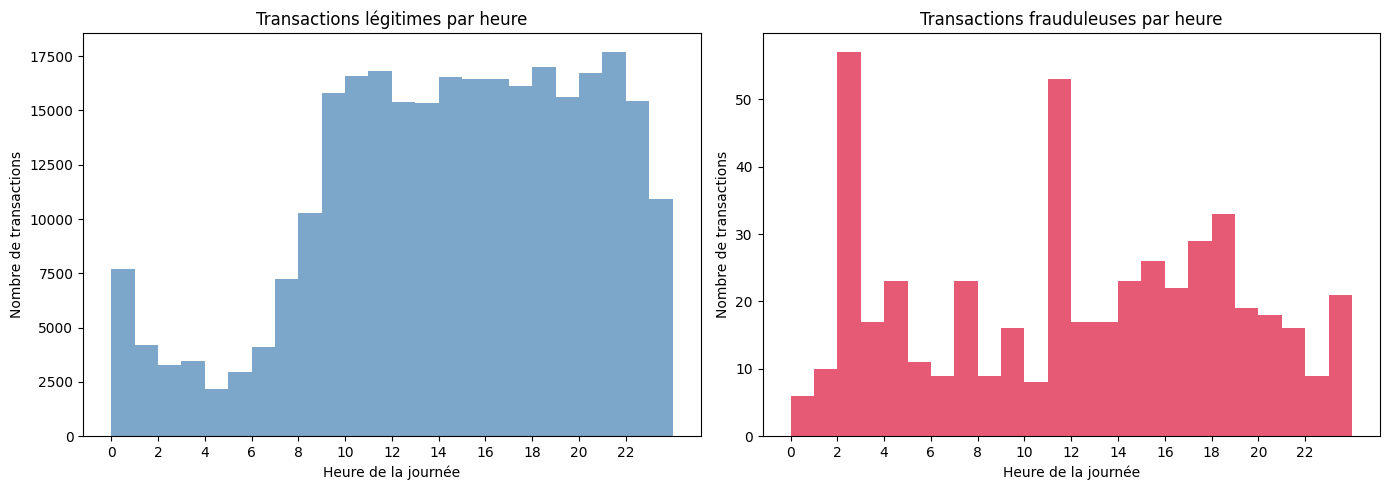


=== Taux de fraude par heure ===
Hour
0.0     0.078
1.0     0.237
2.0     1.713
3.0     0.487
4.0     1.041
5.0     0.368
6.0     0.219
7.0     0.318
8.0     0.088
9.0     0.101
10.0    0.048
11.0    0.314
12.0    0.110
13.0    0.111
14.0    0.139
15.0    0.158
16.0    0.134
17.0    0.179
18.0    0.194
19.0    0.121
20.0    0.107
21.0    0.090
22.0    0.058
23.0    0.192


In [5]:
df['Hour'] = (df['Time'] % 86400) // 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions légitimes par heure
legit_hours = df[df['Class'] == 0]['Hour']
fraud_hours = df[df['Class'] == 1]['Hour']

axes[0].hist(legit_hours, bins=24, range=(0, 24), color='steelblue', alpha=0.7)
axes[0].set_title('Transactions légitimes par heure')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xticks(range(0, 24, 2))

axes[1].hist(fraud_hours, bins=24, range=(0, 24), color='crimson', alpha=0.7)
axes[1].set_title('Transactions frauduleuses par heure')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Nombre de transactions')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("\n=== Taux de fraude par heure ===")
fraud_rate = df.groupby('Hour')['Class'].mean() * 100
print(fraud_rate.round(3).to_string())

### Observation

**Transactions légitimes — comportement humain classique**
La courbe suit parfaitement le rythme de vie humain : creux profond entre 2h et 8h
(les gens dorment), montée progressive dès 9h, plateau élevé de 10h à 22h.
C'est le pattern attendu pour des achats par carte réels.

**Transactions frauduleuses — pattern radicalement différent**
La distribution est beaucoup plus irrégulière et ne suit pas le rythme humain.
On observe notamment un **pic massif à 2h–3h du matin** alors que les transactions
légitimes sont au plus bas à cette heure.

**Taux de fraude par heure — chiffres clés**

| Heure | Taux de fraude |
|-------|---------------|
| 2h    | **1.71%**     |
| 4h    | **1.04%**     |
| 3h    | 0.49%         |
| Journée (8h–22h) | 0.05% – 0.20% |

À 2h du matin, le taux de fraude est **10x supérieur** à la moyenne de la journée.
Pourquoi ? À cette heure les clients ne surveillent pas leurs comptes,
les équipes de fraude sont réduites, et les alertes passent inaperçues plus longtemps.

**Décision :** la feature `Hour` qu'on vient de créer sera conservée dans nos modèles.
C'est une feature ingénierée à partir de `Time` — un exemple concret de **feature engineering**.
`Time` brut était peu utile, `Hour` l'est beaucoup plus.

## 5. Analyse des features V1–V28 — corrélations avec la fraude

=== Top 10 features les plus corrélées avec Class ===
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


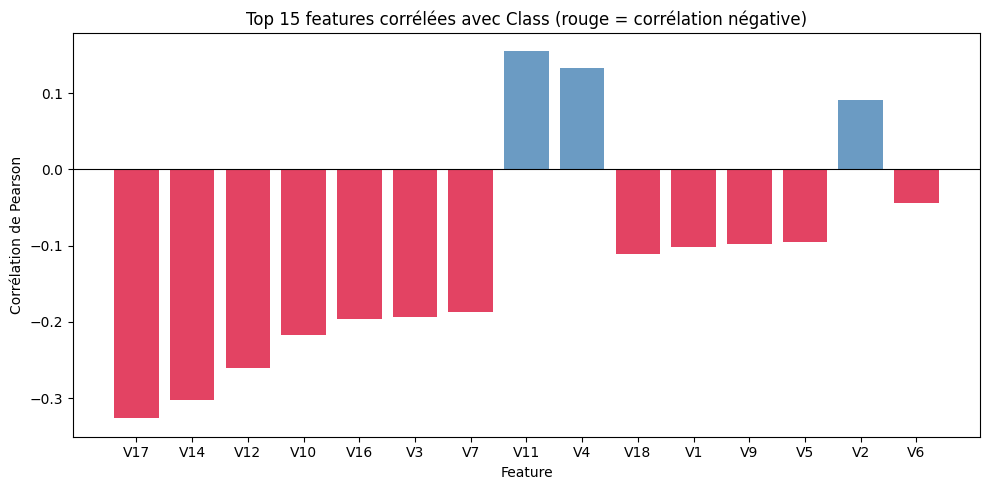

In [6]:
correlations = df.drop(columns=['Time', 'Hour']).corr()['Class'].drop('Class')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("=== Top 10 features les plus corrélées avec Class ===")
print(correlations_sorted.head(10).round(4))

plt.figure(figsize=(10, 5))
colors = ['crimson' if correlations[f] < 0 else 'steelblue' 
          for f in correlations_sorted.head(15).index]
plt.bar(correlations_sorted.head(15).index, 
        correlations[correlations_sorted.head(15).index], 
        color=colors, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Top 15 features corrélées avec Class (rouge = corrélation négative)')
plt.xlabel('Feature')
plt.ylabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

### Observation

**La corrélation de Pearson mesure la relation linéaire entre chaque feature et la cible.**
Une valeur proche de -1 ou +1 indique une forte relation, proche de 0 = relation faible.

**Features les plus discriminantes (en valeur absolue) :**

| Feature | Corrélation | Interprétation |
|---------|-------------|----------------|
| V17 | -0.327 | Plus V17 est bas, plus c'est probablement une fraude |
| V14 | -0.303 | Idem — signal fort |
| V12 | -0.261 | Signal fort négatif |
| V11 | +0.155 | Signal positif — valeur haute = suspect |
| V4  | +0.133 | Signal positif modéré |

**Corrélations négatives (rouge) — la majorité**
La plupart des features discriminantes ont une corrélation négative :
une valeur **anormalement basse** de V17, V14, V12 signale une fraude.
C'est cohérent avec le fait que la PCA produit des composantes centrées sur zéro —
les fraudes s'écartent dans le sens négatif pour ces dimensions.

**Limite importante de cette analyse**
La corrélation de Pearson ne capture que les relations **linéaires**.
Un modèle non-linéaire comme XGBoost ou Random Forest peut exploiter des patterns
que cette corrélation ne détecte pas. Ces valeurs donnent une première indication,
pas une sélection définitive de features.

**Décision :** V17, V14, V12, V10, V16 seront des features à surveiller de près
lors de l'analyse SHAP en phase de modélisation. On garde toutes les features pour l'instant.

## 6. Distribution de V17 et V14 — fraude vs légitime

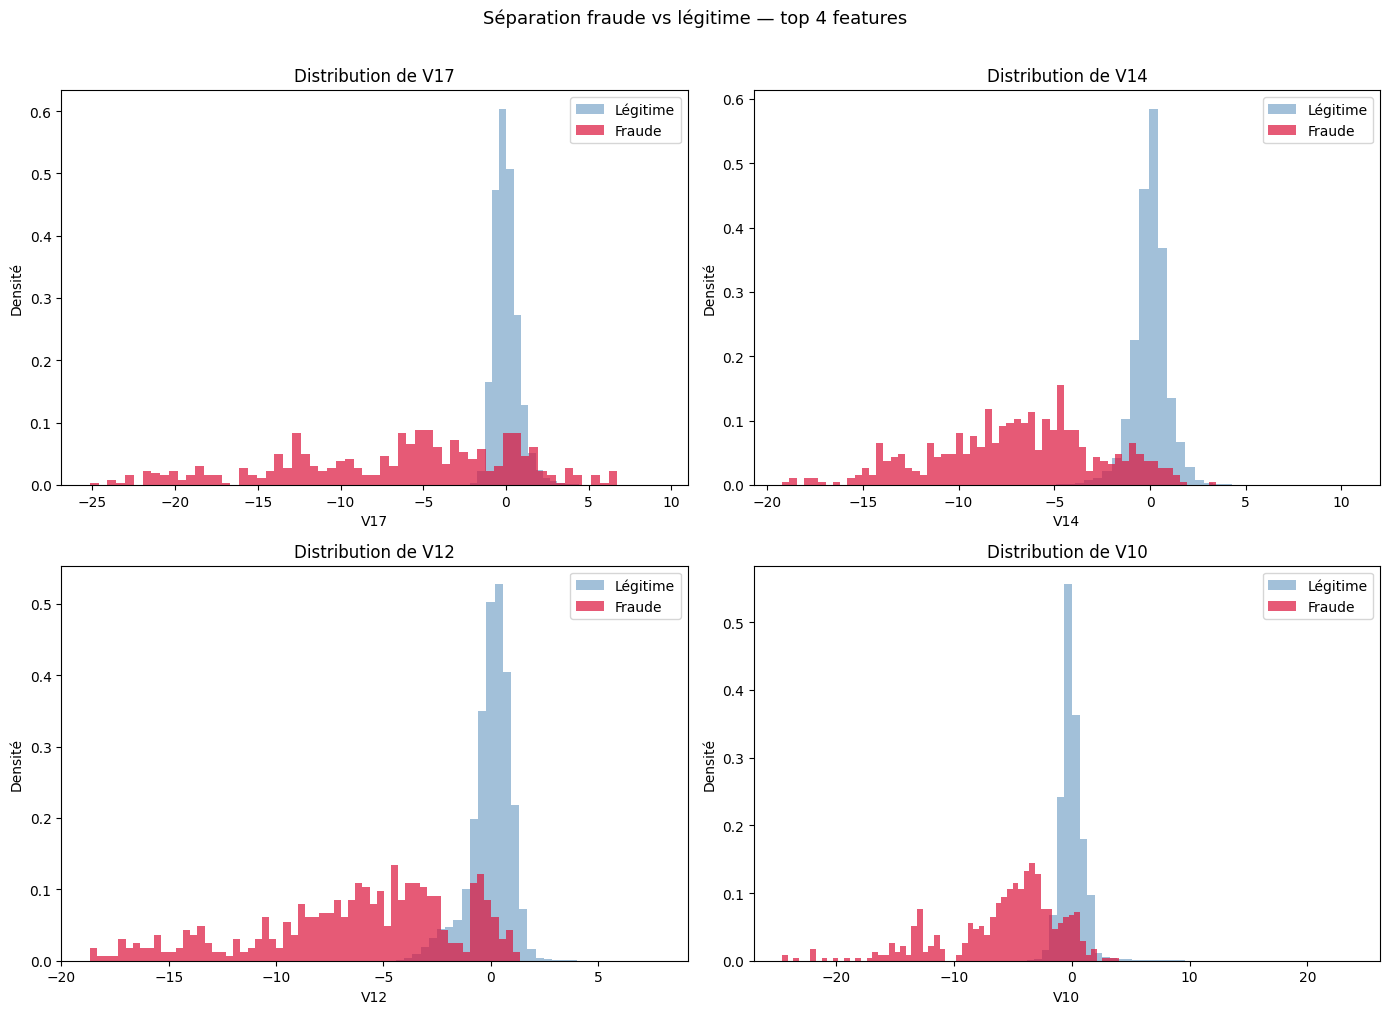

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_features = ['V17', 'V14', 'V12', 'V10']

for i, feat in enumerate(top_features):
    ax = axes[i // 2][i % 2]
    fraud_vals = df[df['Class'] == 1][feat]
    legit_vals  = df[df['Class'] == 0][feat]
    
    ax.hist(legit_vals, bins=60, alpha=0.5, color='steelblue', 
            label='Légitime', density=True)
    ax.hist(fraud_vals, bins=60, alpha=0.7, color='crimson',  
            label='Fraude',   density=True)
    ax.set_title(f'Distribution de {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Densité')
    ax.legend()

plt.suptitle('Séparation fraude vs légitime — top 4 features', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Observation

**C'est la visualisation la plus importante de l'EDA.**
On utilise `density=True` pour comparer les formes des distributions indépendamment
du nombre de transactions — sinon les légitimes (284k) écraseraient visuellement
les fraudes (492) à cause du déséquilibre.

**Pattern commun aux 4 features**
Les transactions légitimes forment un **pic étroit et très concentré autour de 0**.
C'est la signature de la PCA : les transactions normales sont regroupées,
prévisibles, peu dispersées.

Les transactions frauduleuses au contraire sont **étalées largement vers les valeurs
négatives** (-5 à -25), avec une distribution plate et diffuse.
Ce sont des valeurs statistiquement anormales — loin de ce qu'un comportement
normal produirait.

**Ce que ça signifie concrètement pour nos modèles**
Ces features sont de bons séparateurs car les deux distributions se chevauchent peu.
Un seuil simple sur V17 < -5 ou V14 < -5 capturerait déjà une bonne partie des fraudes.
C'est exactement ce qu'un arbre de décision va apprendre automatiquement.

**Nuance importante**
La distribution rouge (fraude) a quand même une masse autour de 0 qui chevauche
le bleu — il reste des fraudes "invisibles" qui ressemblent à des transactions légitimes.
Ce sont les cas les plus difficiles à détecter, et c'est là que XGBoost
battra une simple régression logistique.

## 7. Récapitulatif de l'EDA

In [8]:
print("=" * 55)
print("RÉCAPITULATIF EDA")
print("=" * 55)

print(f"\n Dataset : {df.shape[0]:,} transactions, {df.shape[1]} colonnes")
print(f" Valeurs manquantes : 0")
print(f" Fraudes : {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%)")
print(f" Ratio déséquilibre : 1 fraude / {int((1-df['Class'].mean())/df['Class'].mean())} légitimes")

print("\n Features créées :")
print("  - Hour : heure extraite de Time (pic de fraude à 2h–3h)")
print("  - log1p(Amount) : à appliquer avant modélisation")

print("\n Top features discriminantes :")
top = ['V17', 'V14', 'V12', 'V10', 'V16']
corrs = df[top].corrwith(df['Class']).round(3)
for f, c in corrs.items():
    print(f"  {f} : {c}")

print("\n Décisions pour la phase suivante :")
print("  [1] Scaler Amount avec log1p + StandardScaler")
print("  [2] Scaler Time ou garder Hour")
print("  [3] Gérer le déséquilibre : class_weight ou SMOTE")
print("  [4] Métriques : Recall, Precision, F1, AUC-ROC")
print("  [5] Modèles : Logistic Regression → Random Forest → XGBoost")

RÉCAPITULATIF EDA

 Dataset : 284,807 transactions, 32 colonnes
 Valeurs manquantes : 0
 Fraudes : 492 (0.173%)
 Ratio déséquilibre : 1 fraude / 577 légitimes

 Features créées :
  - Hour : heure extraite de Time (pic de fraude à 2h–3h)
  - log1p(Amount) : à appliquer avant modélisation

 Top features discriminantes :
  V17 : -0.326
  V14 : -0.303
  V12 : -0.261
  V10 : -0.217
  V16 : -0.197

 Décisions pour la phase suivante :
  [1] Scaler Amount avec log1p + StandardScaler
  [2] Scaler Time ou garder Hour
  [3] Gérer le déséquilibre : class_weight ou SMOTE
  [4] Métriques : Recall, Precision, F1, AUC-ROC
  [5] Modèles : Logistic Regression → Random Forest → XGBoost


### Conclusion de l'EDA

| Constat | Impact sur la modélisation |
|---------|---------------------------|
| 0 valeur manquante | Pas d'imputation nécessaire |
| Déséquilibre 1/577 | Ne pas utiliser l'accuracy — utiliser F1/AUC |
| Amount skewed right | Appliquer log1p + StandardScaler |
| Pic de fraude à 2h–3h | Garder `Hour` comme feature engineerée |
| V17, V14, V12 très discriminants | Features prioritaires pour SHAP |
| Fraudes étalées vers valeurs négatives | Les arbres de décision vont bien séparer |

L'EDA est terminée. La phase suivante est le **preprocessing** :
scaling, encodage, gestion du déséquilibre, puis modélisation.